###### Load Dependencies

In [73]:
from importlib import reload
import scalers
from data import *
from classifications import *
from imputers import *
from scalers import StandardScaler, NormalScaler
import data as db
import matplotlib.pyplot as plt
reload( db )
import pandas as pd
import warnings

In [74]:
hdr = '\r\n' + '-' * 120 + '\r\n'
nwln = '\r\n'
warnings.filterwarnings( 'ignore' )

###### Load Data

In [75]:
# Load Data
schedx_filepath = r'C:\Users\terry\source\repos\mathy\stores\excel\Combined Schedules.xlsx'
nominal_columns = [ 'MainAccount', 'TreasurySymbol', 'AccountName',
					'LineName', 'Line', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
out_years = [ f'OY-{i}' for i in range( 1, 10 ) ]
numeric_columns = [ 'PY', 'CY', 'BY' ]
data_columns = [ 'MainAccount', 'Line' ]
all_columns = nominal_columns + numeric_columns
index_columns = [ 'CombinedSchedulesId', ]
drop_columns = [ 'LineName', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
max_columns = data_columns + numeric_columns

# Read Excel, set index and load columns# Reload with corrected dtypes and padding for codes
dtype_dict = \
{
	'MainAccount': str,
	'TreasurySymbol': str
}

df_excel = pd.read_excel( schedx_filepath, usecols=all_columns, sheet_name='Data'  )
df_excel.reset_index( )
df_excel.round( 2 )
# Fix formatting: pad with leading zeros and split TreasurySymbol
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.replace( 'A-', '', regex=False )
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.zfill( 4 )
df_excel[ 'TreasurySymbol' ] = df_excel[ 'TreasurySymbol' ].str.replace( 'A-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.replace( 'L-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.zfill( 4 )
df_excel[ 'AgencyCode' ] = df_excel[ 'TreasurySymbol' ].str[ :3 ].str.zfill( 3 )
df_excel[ 'MainAccountCode' ] = df_excel[ 'TreasurySymbol' ].str[ 3: ].str.zfill( 4 )

df_excel[ numeric_columns ] = df_excel[ numeric_columns ].round( 2 )
df_dataset = df_excel[ all_columns ].copy( )
df_nominal = df_excel[ nominal_columns ].copy( )
df_numeric = df_excel[ numeric_columns ].copy( )
df_schedx = df_excel[ max_columns ].copy( )
sns.set_style( 'darkgrid' )

In [77]:
ds = db.DataSource( df=df_schedx, target='BY' )
data = ds.data
targets = ds.targets.to_numpy( )
training_data = ds.X_train
training_values = ds.y_train
testing_data = ds.X_test
testing_values = ds.y_test

In [78]:
# Standardized data
scaler = StandardScaler( )
standardized_training = scaler.train_transform( training_data )
standardized_testing = scaler.train_transform( testing_data )

# Normalized data
normal = NormalScaler( )
normal_training = normal.train_transform( training_data )
normal_testing = normal.train_transform( testing_data )

In [99]:
knn = NearestNeighbor( )
knn.train( X=data, y=targets )
score = knn.score( data, targets)
analysis = knn.analyze( data, targets )

In [101]:
score

np.float64(1.1951803582821974e+16)

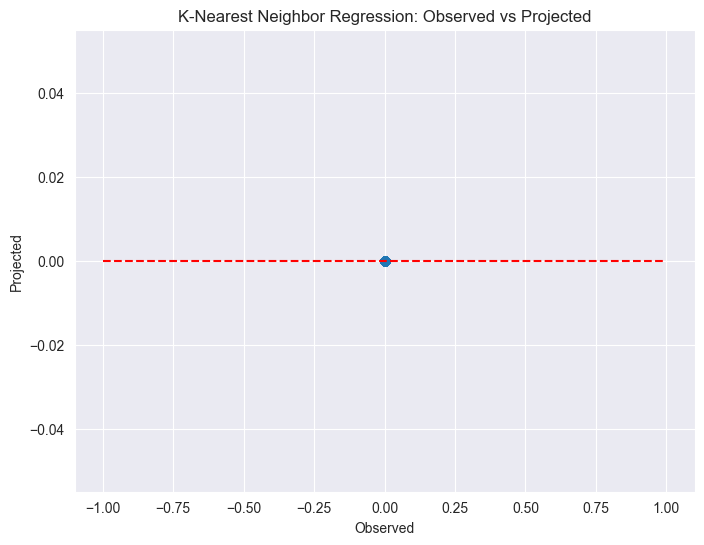

In [83]:
knn.scatter_plot( normal_testing, y_testing )

In [81]:
knn.analyze( normal_training, y_training )

{'MSE': 0.0, 'RMSE': 0.0, 'R2': 1.0, 'EVS': 1.0, 'MAE': 0.0}

array([[0.00196977, 0.0021839 , 0.00220955, ..., 0.00253547, 0.00253512,
        0.0025354 ],
       [0.00231063, 0.00233243, 0.00233491, ..., 0.00236433, 0.0023643 ,
        0.00236433],
       [0.00233435, 0.00234211, 0.002343  , ..., 0.00235339, 0.00235338,
        0.00235339],
       ...,
       [0.00233769, 0.00234328, 0.00234399, ..., 0.00235371, 0.0023537 ,
        0.00235371],
       [0.00233848, 0.00234357, 0.00234424, ..., 0.00235366, 0.00235365,
        0.00235366],
       [0.0002071 , 0.00032634, 0.00040011, ..., 0.05997735, 0.06003489,
        0.06004328]], shape=(2400, 426))